# 🚗 License Plate Recognition — Adaptive Image Processing Pipeline

| Function | Member | Stage | Adaptive Behaviour |
|---|---|---|---|
| `m1_edge_detection` | M1 | Grayscale + CLAHE + Bilateral + Canny | Auto-tunes Canny thresholds via Otsu; CLAHE for dark/bright images |
| `m2_plate_candidate` | M2 | Morph Closing + Contour Filtering | Multi-pass search with relaxing constraints; scoring by position+area+aspect |
| `m3_perspective_binarize` | M3 | Perspective Correction + Binarization | Picks Otsu vs Adaptive based on local contrast; dynamic output size |


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets
import os, warnings
warnings.filterwarnings('ignore')
print('Libraries loaded ✓')

Libraries loaded ✓


## 1: Adaptive Grayscale + Bilateral Filter + Edge Detection

In [11]:
def m1_edge_detection(image_path, visualize=True):
    original = cv2.imread(image_path)
    if original is None:
        raise FileNotFoundError(f"Cannot open image: {image_path}")

    h, w = original.shape[:2]
    gray_raw = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

    mean_intensity = np.mean(gray_raw)
    contrast = np.std(gray_raw)
    texture = cv2.Laplacian(gray_raw, cv2.CV_64F).var()

    # CLAHE: more conservative scaling (less noise amplification)
    clip = np.clip(2.0 + (50.0 / (contrast + 1e-5)), 2.0, 5.0)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    gray = clahe.apply(gray_raw)

    # Bilateral: driven more by texture than raw std
    base = max(5, min(15, int(min(h, w) / 60) * 2 + 1))
    sigma = np.clip(0.3 * contrast + 0.2 * texture**0.5, 10, 60)

    filtered = cv2.bilateralFilter(gray, base, sigma, sigma)

    # Canny: still Otsu-based but stabilized
    blurred = cv2.GaussianBlur(filtered, (5, 5), 0)
    otsu_val, _ = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    edge_density_bias = np.clip(texture / 1000.0, 0.8, 1.3)

    canny_low = int(np.clip(0.4 * otsu_val * edge_density_bias, 10, 120))
    canny_high = int(np.clip(1.2 * otsu_val * edge_density_bias, 80, 250))

    edges = cv2.Canny(filtered, canny_low, canny_high)

    meta = dict(
        clip=round(clip, 2),
        bilateral_d=base,
        sigma=round(float(sigma), 2),
        canny=[canny_low, canny_high],
        mean=int(mean_intensity),
        contrast=round(contrast, 1),
        texture=round(texture, 1)
    )

    if visualize:
        fig, axes = plt.subplots(1, 4, figsize=(20, 4))
        axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Original {w}x{h}")
        axes[1].imshow(gray_raw, cmap="gray")
        axes[1].set_title("Grayscale")
        axes[2].imshow(gray, cmap="gray")
        axes[2].set_title(f"CLAHE clip={clip:.2f}")
        axes[3].imshow(edges, cmap="gray")
        axes[3].set_title(f"Canny {canny_low}-{canny_high}")

        for ax in axes:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

        print(meta)

    return original, gray, edges, meta

## 2: Adaptive Morph Closing + Contour Filtering

In [12]:
def m2_plate_candidate(original, edges, visualize=True):
    """
    M2: License plate candidate detection.
    Uses the proven PyImageSearch ANPR approach:
      1. BLACKHAT morphology to reveal dark text on light plates
      2. TOPHAT morphology to reveal light text on dark plates
      3. Scharr gradient in x-direction to find character regions
      4. Otsu threshold + morphological cleanup
      5. Contour ranking with adaptive aspect/size filters
    Works on both light-background and dark-background plates.
    Returns: plate_crop (BGR), best_contour, best_rect (x,y,w,h), meta
    """
    img_h, img_w = edges.shape
    img_area     = img_h * img_w

    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

    # ── Step 1: Adaptive rect kernel (scaled to image size) ─────────
    # Standard plate ratio ~13:5 scaled to image
    kw = max(13, int(img_w * 0.025)) | 1
    kh = max(5,  int(img_h * 0.015)) | 1
    rect_kern = cv2.getStructuringElement(cv2.MORPH_RECT, (kw, kh))
    sq_kern   = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

    # ── Step 2: BLACKHAT — dark text on light plate ──────────────────
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, rect_kern)

    # ── Step 3: TOPHAT — light text on dark plate ────────────────────
    tophat   = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT,   rect_kern)

    # ── Step 4: Scharr gradient (x-direction) on each ───────────────
    def scharr_thresh(img):
        grad = cv2.Scharr(img, cv2.CV_32F, 1, 0)
        grad = np.absolute(grad)
        mn, mx = grad.min(), grad.max()
        if mx - mn < 1e-5:
            return np.zeros_like(img, dtype=np.uint8)
        grad = (255 * (grad - mn) / (mx - mn)).astype(np.uint8)
        blurred = cv2.GaussianBlur(grad, (5, 5), 0)
        _, thresh = cv2.threshold(
            blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )
        # close gaps between characters
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, rect_kern)
        # denoise
        thresh = cv2.erode(thresh,  sq_kern, iterations=2)
        thresh = cv2.dilate(thresh, sq_kern, iterations=2)
        return thresh

    thresh_black = scharr_thresh(blackhat)
    thresh_top   = scharr_thresh(tophat)

    # ── Step 5: Also try traditional edge-based morph ────────────────
    morph_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, rect_kern)

    sources = [
        ("blackhat", thresh_black),
        ("tophat",   thresh_top),
        ("edges",    morph_edges),
    ]

    # ── Step 6: Contour scoring ──────────────────────────────────────
    def score_contour(cnt, x, y, w, h):
        area     = w * h
        ar_frac  = area / float(img_area)
        aspect   = w / float(h + 1e-5)

        # Hard gates — must pass ALL
        if ar_frac < 0.003 or ar_frac > 0.40:   return -1  # too small/large
        if aspect   < 1.0  or aspect   > 9.0:    return -1  # wrong shape
        if w < img_w * 0.04:                      return -1  # too narrow
        if h > img_h * 0.25:                      return -1  # too tall
        # reject near-full-image boxes
        if w > img_w * 0.90 and h > img_h * 0.90: return -1

        # Soft scoring
        asp_score  = max(0.0, 1.0 - abs(aspect - 4.0) / 5.0)
        fill       = cv2.contourArea(cnt) / (area + 1e-5)
        edge_den   = float(np.mean(edges[y:y+h, x:x+w])) / 255.0
        y_c        = (y + h / 2.0) / img_h
        pos        = 1.0 + 0.4 * (0.25 < y_c < 0.95)
        size_score = 1.0 - ar_frac   # prefer smaller (not full image)

        return (0.30 * asp_score +
                0.25 * fill       +
                0.25 * edge_den   +
                0.20 * size_score ) * pos

    best_score   = -1
    best_contour = None
    best_rect    = None
    best_source  = None

    for sname, thresh in sources:
        cnts, _ = cv2.findContours(
            thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        # sort by area descending, check top 10 only (efficiency)
        cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:10]
        for cnt in cnts:
            x, y, w, h = cv2.boundingRect(cnt)
            s = score_contour(cnt, x, y, w, h)
            if s > best_score:
                best_score, best_contour, best_rect, best_source = s, cnt, (x,y,w,h), sname

    # ── Step 7: Relaxed fallback (drop size/aspect gates) ───────────
    if best_contour is None:
        print("[M2] Strict pass found nothing — relaxed fallback")
        for sname, thresh in sources:
            cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:5]
            for cnt in cnts:
                x, y, w, h = cv2.boundingRect(cnt)
                if w * h < img_area * 0.001:        continue
                if w > img_w * 0.92 and h > img_h * 0.92: continue
                s = float(np.mean(edges[y:y+h, x:x+w])) / 255.0
                if s > best_score:
                    best_score, best_contour, best_rect, best_source = s, cnt, (x,y,w,h), sname+"_relaxed"

    # ── Last resort ──────────────────────────────────────────────────
    if best_contour is None:
        print("[M2] No candidate found — full image fallback")
        best_rect    = (0, 0, img_w, img_h)
        best_contour = np.array([[[0,0]],[[img_w,0]],[[img_w,img_h]],[[0,img_h]]])
        best_source  = "fallback"
        best_score   = 0.0

    # ── Padding ──────────────────────────────────────────────────────
    x, y, w, h = best_rect
    pad_x = max(4, int(w * 0.03))
    pad_y = max(4, int(h * 0.06))
    x1 = max(0,     x - pad_x)
    y1 = max(0,     y - pad_y)
    x2 = min(img_w, x + w + pad_x)
    y2 = min(img_h, y + h + pad_y)
    best_rect  = (x1, y1, x2-x1, y2-y1)
    plate_crop = original[y1:y2, x1:x2]

    meta = {
        "score":  round(best_score, 4),
        "source": best_source,
        "kernel": f"{kw}x{kh}",
        "rect":   best_rect,
    }

    if visualize:
        debug = original.copy()
        rx, ry, rw, rh = best_rect
        cv2.rectangle(debug, (rx, ry), (rx+rw, ry+rh), (0, 220, 60), 3)
        cv2.putText(debug, f"{best_source} | score={best_score:.3f}",
                    (rx, max(ry-10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,220,60), 2)

        fig, axes = plt.subplots(1, 4, figsize=(22, 4))
        axes[0].imshow(blackhat, cmap="gray");                          axes[0].set_title("Blackhat")
        axes[1].imshow(tophat,   cmap="gray");                          axes[1].set_title("Tophat")
        axes[2].imshow(cv2.cvtColor(debug, cv2.COLOR_BGR2RGB));         axes[2].set_title(f"Detection [{best_source}]")
        axes[3].imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB));    axes[3].set_title("Plate Crop")
        for ax in axes: ax.axis("off")
        plt.tight_layout(); plt.show()
        print("[M2]", meta)

    return plate_crop, best_contour, best_rect, meta


## 3: Adaptive Perspective Correction + Binarization

In [13]:
def m3_perspective_binarize(original, best_rect, edges=None, visualize=True):
    """
    M3: Perspective correction + adaptive binarization (robust version)

    Key upgrades:
      - Multi-candidate warping (quad + rotated rect + fallback)
      - Warp quality scoring instead of single-path trust
      - Realistic aspect ratio constraints (not strict inheritance from M2)
      - Data-driven binarization selection (Otsu vs Adaptive)
      - Post-warp validation signal

    Returns:
      binary_plate, best_warped, meta
    """

    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    x, y, w, h = best_rect

    crop_gray = gray[y:y+h, x:x+w]

    # ----------------------------
    # Step 1: edge + contour search
    # ----------------------------
    blurred = cv2.GaussianBlur(crop_gray, (3, 3), 0)
    _, crop_edges = cv2.threshold(
        blurred, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    contours, _ = cv2.findContours(
        crop_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    # ----------------------------
    # Step 2: candidate geometry extraction
    # ----------------------------
    candidates = []

    # A) Best contour quad attempt
    if contours:
        biggest = max(contours, key=cv2.contourArea)
        peri = cv2.arcLength(biggest, True)

        for eps in [0.02, 0.03, 0.05, 0.08]:
            approx = cv2.approxPolyDP(biggest, eps * peri, True)
            if len(approx) == 4:
                quad = approx.reshape(4, 2).astype(np.float32)
                quad[:, 0] += x
                quad[:, 1] += y
                candidates.append(("quad", quad))
                break

    # B) Rotated rectangle fallback
    rect = cv2.minAreaRect(
        max(contours, key=cv2.contourArea)
    ) if contours else None

    if rect is not None:
        box = cv2.boxPoints(rect).astype(np.float32)
        box[:, 0] += x
        box[:, 1] += y
        candidates.append(("rotated_rect", box))

    # C) Hard fallback bounding box
    candidates.append((
        "bbox",
        np.array([[x, y], [x+w, y], [x+w, y+h], [x, y+h]], dtype=np.float32)
    ))

    # ----------------------------
    # Step 3: geometry ordering
    # ----------------------------
    def order_points(pts):
        rect = np.zeros((4, 2), dtype=np.float32)
        s = pts.sum(axis=1)
        d = np.diff(pts, axis=1).ravel()
        rect[0] = pts[np.argmin(s)]
        rect[2] = pts[np.argmax(s)]
        rect[1] = pts[np.argmin(d)]
        rect[3] = pts[np.argmax(d)]
        return rect

    # ----------------------------
    # Step 4: warp scoring function
    # ----------------------------
    def warp_score(warp):
        if warp is None:
            return -1

        # warp is already grayscale (warped from gray via warpPerspective)
        g = warp if len(warp.shape) == 2 else cv2.cvtColor(warp, cv2.COLOR_BGR2GRAY)

        # character structure signal
        edge_var = cv2.Laplacian(g, cv2.CV_64F).var()

        # binarization stability proxy
        std = np.std(g)

        # foreground balance (not too empty, not too full)
        _, bin_tmp = cv2.threshold(
            g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )
        fg_ratio = np.mean(bin_tmp == 255)

        balance = 1.0 - abs(fg_ratio - 0.5)

        return (
            0.5 * min(edge_var / 500.0, 1.0) +
            0.3 * balance +
            0.2 * min(std / 80.0, 1.0)
        )

    # ----------------------------
    # Step 5: warp + evaluation
    # ----------------------------
    best_warp = None
    best_binary = None
    best_meta = None
    best_score = -1

    for mode, pts in candidates:
        src = order_points(pts)

        # adaptive output size (clamped realism)
        h_out = 80
        aspect = w / float(h + 1e-5)
        aspect = np.clip(aspect, 2.0, 6.5)
        w_out = int(np.clip(h_out * aspect, 160, 480))

        dst = np.array(
            [[0, 0], [w_out-1, 0], [w_out-1, h_out-1], [0, h_out-1]],
            dtype=np.float32
        )

        M = cv2.getPerspectiveTransform(src, dst)
        warped = cv2.warpPerspective(gray, M, (w_out, h_out))

        score = warp_score(warped)

        if score > best_score:
            best_score = score
            best_warp = warped
            best_meta = mode

    # ----------------------------
    # Step 6: adaptive binarization
    # ----------------------------
    local_std = float(np.std(best_warp))

    otsu_bin = cv2.threshold(
        best_warp, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )[1]

    block = max(11, int(best_warp.shape[1] / 15) | 1)
    adaptive_bin = cv2.adaptiveThreshold(
        best_warp, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        block, 4
    )

    def bin_quality(b):
        return np.mean(b == 255) * np.std(b)

    binary = otsu_bin if bin_quality(otsu_bin) > bin_quality(adaptive_bin) else adaptive_bin

    # fix polarity
    if np.mean(binary) < 127:
        binary = cv2.bitwise_not(binary)

    binary = cv2.medianBlur(binary, 3)

    meta = {
        "warp_mode": best_meta,
        "warp_score": round(best_score, 4),
        "local_std": round(local_std, 1),
        "out_size": best_warp.shape[::-1],
        "binarization": "otsu_vs_adaptive"
    }

    # ----------------------------
    # Step 7: visualization
    # ----------------------------
    if visualize:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        axes[0].imshow(gray[y:y+h, x:x+w], cmap="gray")
        axes[0].set_title("Input Crop (M2)")

        axes[1].imshow(best_warp, cmap="gray")
        axes[1].set_title(f"Warped [{best_meta}] score={best_score:.3f}")

        axes[2].imshow(binary, cmap="gray")
        axes[2].set_title(f"Binary std={local_std:.0f}")

        for ax in axes:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

        print("[M3]", meta)

    return binary, best_warp, meta

In [14]:
def m4_segment_characters(binary_image, visualize=True):
    """
    Segment characters from binarized license plate.
    
    Args:
        binary_image: Binary image from M3 (black chars, white background, or vice versa)
        visualize: Show segmentation steps and results
    
    Returns:
        character_images: List of segmented character images (resized to ~20×30)
        char_image_paths: List of paths where character images were saved
        meta: Dictionary with segmentation metadata
    """
    


    white_pixels = np.sum(binary_image == 255)
    black_pixels = np.sum(binary_image == 0)
    if white_pixels > black_pixels:
        binary_image = cv2.bitwise_not(binary_image)

        
    # Ensure binary image is uint8 format
    if binary_image.dtype != np.uint8:
        binary_image = (binary_image * 255).astype(np.uint8)
    
    # If binary image has 3 channels, convert to grayscale
    if len(binary_image.shape) == 3:
        binary_image = cv2.cvtColor(binary_image, cv2.COLOR_BGR2GRAY)
    
    h, w = binary_image.shape
    
    # Ensure text is black on white background (if not, invert)
    white_pixels = np.sum(binary_image == 255)
    black_pixels = np.sum(binary_image == 0)
    if black_pixels > white_pixels:
        binary_image = cv2.bitwise_not(binary_image)
    
    # ============================================
    # Step 1: Remove small noisy components (morph open)
    # ============================================
    
    # Adaptive kernel size based on image dimensions
    kernel_size = max(2, int(min(h, w) / 50))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    
    # Morphological opening to remove noise
    cleaned = cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, kernel)


    erosion_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    cleaned = cv2.erode(cleaned, erosion_kernel, iterations=1)
    
    # Additional noise removal by contour area filtering
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    min_char_area = (h * w) * 0.003  # Minimum 0.3% of plate area
    
    # Create mask with only sufficiently large components
    mask = np.zeros_like(cleaned)
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > min_char_area:
            cv2.drawContours(mask, [cnt], -1, 255, -1)
    
    cleaned = cv2.bitwise_and(cleaned, mask)
    
    # ============================================
    # Step 2: Isolate characters using Connected Components (CCL)
    # ============================================
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        cv2.bitwise_not(cleaned), 
        connectivity=8
    )    
    char_regions = []  # Store (character_image, x_position, y_position)
    
    for i in range(1, num_labels):  # Skip background (label 0)
        x, y, cw, ch, area = stats[i]
        
        # Filter criteria for valid characters
        aspect_ratio = cw / max(ch, 1)
        
        # Character should be:
        # - Height between 5% and 85% of plate height
        # - Width between 2% and 60% of plate width
        # - Aspect ratio between 0.2 and 1.5 (typical for letters/digits)
        # - Area not too small
        if (ch > h * 0.05 and ch < h * 0.85 and
            cw > w * 0.02 and cw < w * 0.60 and
            aspect_ratio > 0.2 and aspect_ratio < 1.5 and
            area > min_char_area):
            
            # Add small padding around character
            pad_x = max(1, int(cw * 0.1))
            pad_y = max(1, int(ch * 0.1))
            
            x1 = max(0, x - pad_x)
            y1 = max(0, y - pad_y)
            x2 = min(w, x + cw + pad_x)
            y2 = min(h, y + ch + pad_y)
            
            char_region = cleaned[y1:y2, x1:x2]
            char_regions.append((char_region, x1, y1))
    
    # ============================================
    # Fallback: Vertical projection if CCL didn't find enough characters
    # ============================================
    
    if len(char_regions) < 3:
        print("[M4] CCL found few characters, falling back to vertical projection...")
        char_regions = vertical_projection_segmentation(cleaned, h, w, min_char_area)
    
    # ============================================
    # Step 3: Sort left-to-right by x-coordinate
    # ============================================
    
    char_regions.sort(key=lambda x: x[1])  # Sort by x position
    
    # ============================================
    # Step 4: Save each character as separate image (20×30 approx)
    # ============================================
    
    # Create directory for character images
    chars_dir = "segmented_chars"
    os.makedirs(chars_dir, exist_ok=True)
    
    character_images = []
    char_image_paths = []
    
    target_h, target_w = 30, 20  # Target dimensions (height × width)
    
    for idx, (char_img, x_pos, y_pos) in enumerate(char_regions):
        # Get current dimensions
        ch_h, ch_w = char_img.shape
        
        # Calculate scaling to fit within target while preserving aspect ratio
        scale = min(target_w / ch_w, target_h / ch_h)
        new_w = int(ch_w * scale)
        new_h = int(ch_h * scale)
        
        # Resize
        resized = cv2.resize(char_img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
        
        # Create white canvas and center the character
        padded = np.ones((target_h, target_w), dtype=np.uint8) * 255
        x_offset = (target_w - new_w) // 2
        y_offset = (target_h - new_h) // 2
        padded[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
        
        # Save character image
        save_path = os.path.join(chars_dir, f"char_{idx:02d}.png")
        cv2.imwrite(save_path, padded)
        
        character_images.append(padded)
        char_image_paths.append(save_path)
    
    # ============================================
    # Metadata
    # ============================================
    
    meta = {
        "num_characters": len(character_images),
        "method": "CCL" if len(char_regions) >= 3 else "Vertical Projection",
        "target_size": f"{target_h}×{target_w}",
        "output_directory": chars_dir,
        "image_dimensions": f"{w}×{h}"
    }
    
    # ============================================
    # Visualization
    # ============================================
    
    if visualize:
        # 1. Calculate how many columns we need (Characters + 2 for the status images)
        num_chars = len(character_images)
        num_cols = num_chars + 2
        
        # 2. Adjust figsize width dynamically so it doesn't get squashed
        fig, axes = plt.subplots(2, num_cols, figsize=(num_cols * 2.5, 7))
        
        # If there's only one column (rare), axes won't be a 2D array, fix that:
        if num_cols == 1: axes = np.expand_dims(axes, axis=1)

        # Original binary
        axes[0, 0].imshow(binary_image, cmap='gray')
        axes[0, 0].set_title("1. Original Binary")
        axes[0, 0].axis('off')
        
        # After morph open (cleaned)
        axes[0, 1].imshow(cleaned, cmap='gray')
        axes[0, 1].set_title("2. After Morph")
        axes[0, 1].axis('off')
        
        for i, char_img in enumerate(character_images):
            col = i + 2
            axes[0, col].imshow(char_img, cmap='gray')
            axes[0, col].set_title(f"Char {i}\n{char_img.shape[1]}x{char_img.shape[0]}")
            axes[0, col].axis('off')
        
        # Bounding boxes (bottom row)
        debug_img = cv2.cvtColor(cleaned, cv2.COLOR_GRAY2BGR)
        for i, (_, x_pos, y_pos) in enumerate(char_regions):
            char_img = char_regions[i][0]
            ch_h, ch_w = char_img.shape
            cv2.rectangle(debug_img, (x_pos, y_pos), (x_pos + ch_w, y_pos + ch_h), (0, 255, 0), 2)
            cv2.putText(debug_img, str(i), (x_pos, y_pos - 5), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
        
        axes[1, 0].imshow(debug_img)
        axes[1, 0].set_title(f"Detected: {len(char_regions)}")
        axes[1, 0].axis('off')
        
        # Hide the extra empty subplots in the second row
        for j in range(1, num_cols):
            axes[1, j].axis('off')

        plt.tight_layout()
        plt.show()
        
        print("\n" + "="*50)
        print("[M4] Segmentation Complete")
        print("="*50)
        print(f"  → Characters found: {len(character_images)}")
        print(f"  → Method used: {meta['method']}")
        print(f"  → Saved to: {chars_dir}/")
        for i, path in enumerate(char_image_paths):
            print(f"      char_{i:02d}.png ({character_images[i].shape[1]}×{character_images[i].shape[0]})")
        print("="*50)
    
    return character_images, char_image_paths, meta

def vertical_projection_segmentation(cleaned, h, w, min_char_area):
    """
    Fallback method: Vertical projection to find character gaps.
    Used when CCL doesn't find enough characters.
    """
    # Vertical projection histogram (sum of white pixels per column)
    vertical_projection = np.sum(cleaned == 0, axis=0)    
    # Find gaps (columns with very few white pixels)
    threshold = np.max(vertical_projection) * 0.2
    
    char_regions = []
    in_character = False
    start_x = 0
    
    for x in range(w):
        if vertical_projection[x] < threshold and in_character:
            # End of character
            if x - start_x > w * 0.01:  # Minimum width
                char_region = cleaned[:, start_x:x]
                char_regions.append((char_region, start_x, 0))
            in_character = False
        elif vertical_projection[x] >= threshold and not in_character:
            # Start of character
            start_x = x
            in_character = True
    
    # Last character
    if in_character and w - start_x > w * 0.01:
        char_region = cleaned[:, start_x:w]
        char_regions.append((char_region, start_x, 0))
    
    return char_regions

## Combined Pipeline

In [15]:
def run_pipeline(image_path, visualize=True):
    """Run M1 -> M2 -> M3 with lightweight validation and failure awareness."""

    sep = "─" * 55

    

    def log(stage, msg):
        print(sep)
        print(f"  {stage}  {msg}")
        print(sep)

    print(sep)
    print("  PIPELINE START")
    print(sep)

    # -----------------------
    # M1
    # -----------------------
    log("M1", "Grayscale + CLAHE + Bilateral + Auto-Canny")

    original, gray, edges, m1 = m1_edge_detection(
        image_path, visualize=visualize
    )

    m1_quality = np.mean(edges) / 255.0

    # crude sanity check
    if m1_quality < 0.01:
        print("M1 warning: extremely low edge signal")

    # -----------------------
    # M2
    # -----------------------
    log("M2", "Morph Closing + Multi-pass Contour Filter")

    plate_crop, contour, best_rect, m2 = m2_plate_candidate(
        original, edges, visualize=visualize
    )

    m2_score = m2.get("score", 0)

    if m2_score < 0.002:
        print("M2 warning: weak plate confidence")

    # fallback detection
    x, y, w, h = best_rect
    if w == original.shape[1] and h == original.shape[0]:
        print("M2 fallback: full-image crop used")

    # -----------------------
    # M3
    # -----------------------
    log("M3", "Perspective Warp + Adaptive Binarization")

    binary, warped, m3 = m3_perspective_binarize(
        original, best_rect, visualize=visualize
    )

    m3_score = m3.get("warp_score", 0)

    if m3_score < 0.2:
        print("M3 warning: low warp confidence (geometry unstable)")


    print("\n[M4] Segmenting characters...")
    character_images, char_paths, m4_meta = m4_segment_characters(binary, visualize=visualize)

    # -----------------------
    # summary
    # -----------------------
    all_meta = {"M1": m1, "M2": m2, "M3": m3, "M4": m4_meta}

    print("\nPIPELINE COMPLETE\n")

    for k, v in all_meta.items():
        print(f"[{k}] {v}")

    # optional global sanity flag
    global_confidence = (m2_score + m3_score) / 2

    print(f"\n Global confidence: {global_confidence:.3f}")

    if global_confidence < 0.15:
        print(" Overall result is unstable — expect OCR failure")

    return binary, all_meta, character_images, char_paths

───────────────────────────────────────────────────────
  PIPELINE START
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M1  Grayscale + CLAHE + Bilateral + Auto-Canny
───────────────────────────────────────────────────────


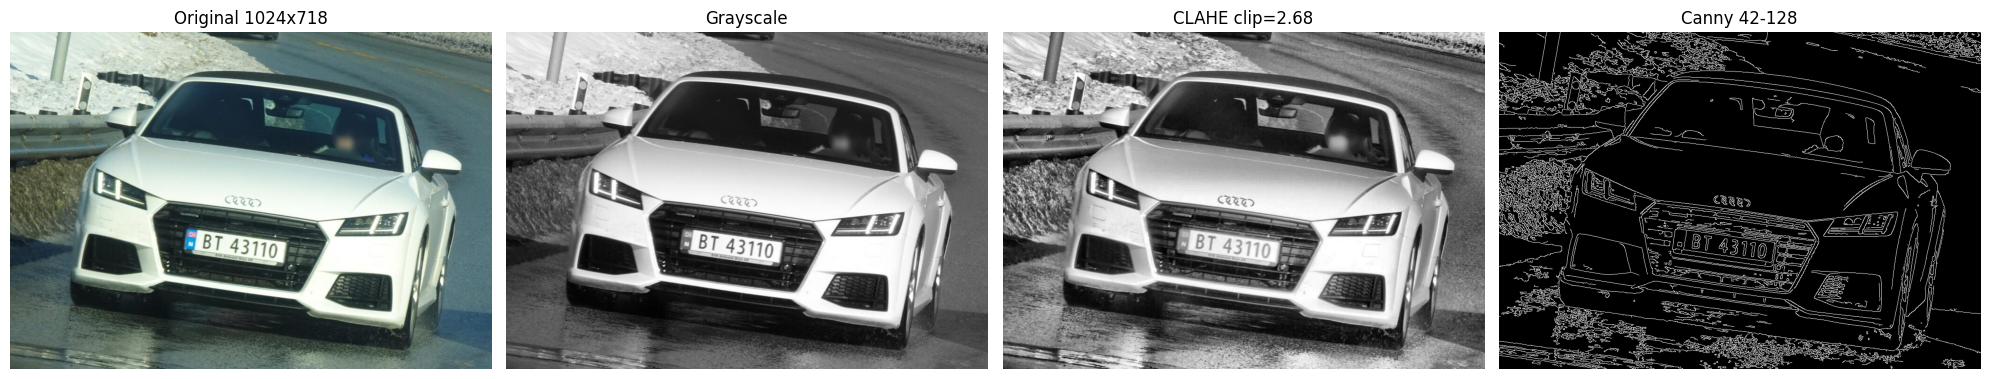

{'clip': np.float64(2.68), 'bilateral_d': 15, 'sigma': 24.81, 'canny': [42, 128], 'mean': 124, 'contrast': np.float64(73.3), 'texture': np.float64(198.0)}
───────────────────────────────────────────────────────
  M2  Morph Closing + Multi-pass Contour Filter
───────────────────────────────────────────────────────


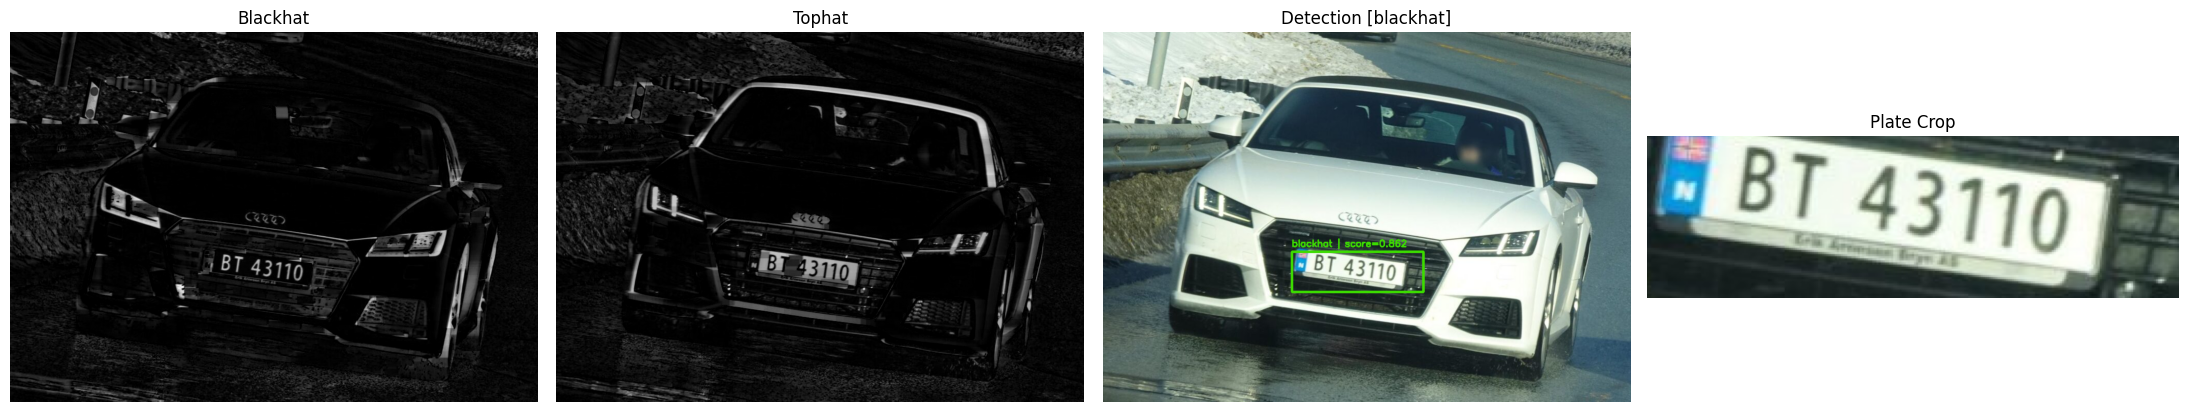

[M2] {'score': 0.8622, 'source': 'blackhat', 'kernel': '25x11', 'rect': (366, 426, 255, 78)}
───────────────────────────────────────────────────────
  M3  Perspective Warp + Adaptive Binarization
───────────────────────────────────────────────────────


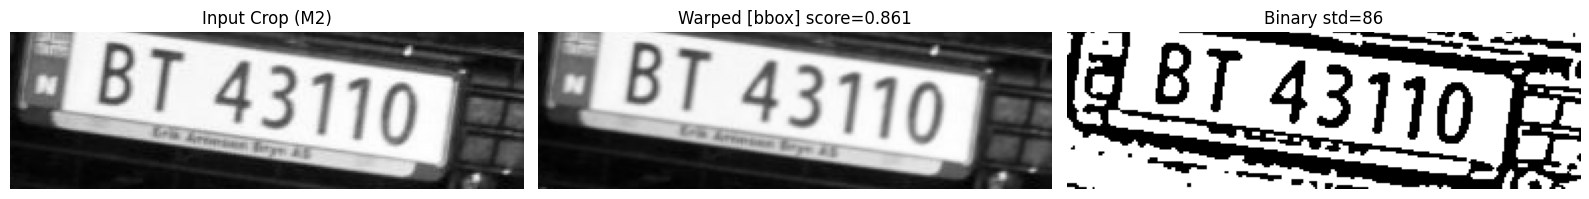

[M3] {'warp_mode': 'bbox', 'warp_score': np.float64(0.8606), 'local_std': 85.8, 'out_size': (261, 80), 'binarization': 'otsu_vs_adaptive'}

[M4] Segmenting characters...


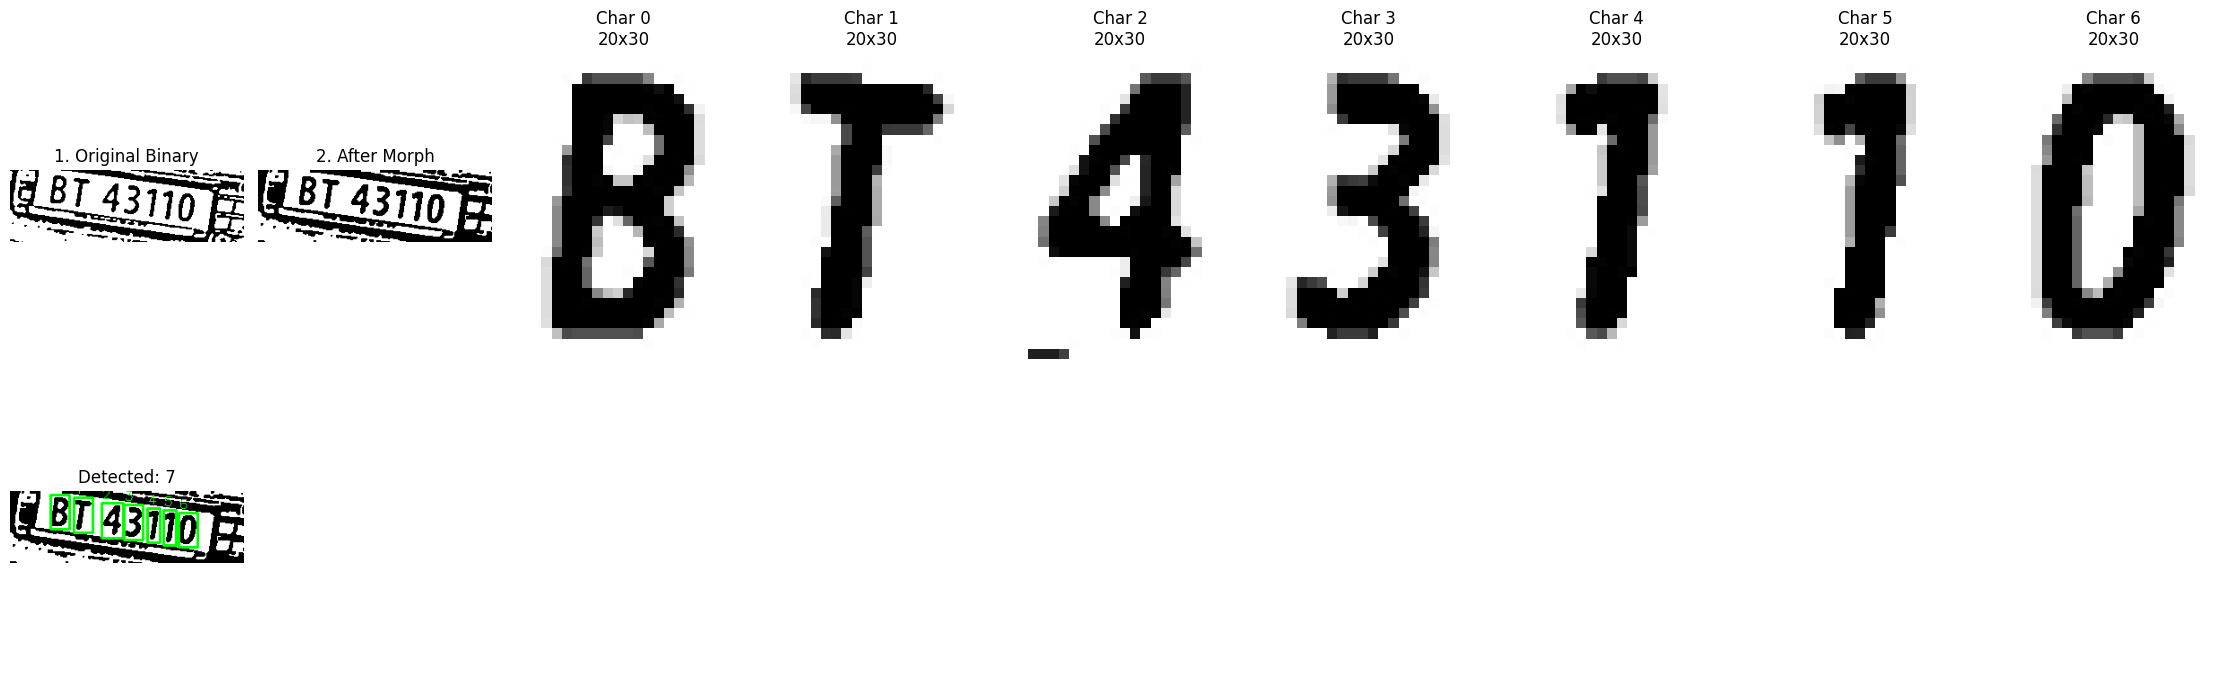


[M4] Segmentation Complete
  → Characters found: 7
  → Method used: CCL
  → Saved to: segmented_chars/
      char_00.png (20×30)
      char_01.png (20×30)
      char_02.png (20×30)
      char_03.png (20×30)
      char_04.png (20×30)
      char_05.png (20×30)
      char_06.png (20×30)

PIPELINE COMPLETE

[M1] {'clip': np.float64(2.68), 'bilateral_d': 15, 'sigma': 24.81, 'canny': [42, 128], 'mean': 124, 'contrast': np.float64(73.3), 'texture': np.float64(198.0)}
[M2] {'score': 0.8622, 'source': 'blackhat', 'kernel': '25x11', 'rect': (366, 426, 255, 78)}
[M3] {'warp_mode': 'bbox', 'warp_score': np.float64(0.8606), 'local_std': 85.8, 'out_size': (261, 80), 'binarization': 'otsu_vs_adaptive'}
[M4] {'num_characters': 7, 'method': 'CCL', 'target_size': '30×20', 'output_directory': 'segmented_chars', 'image_dimensions': '261×80'}

 Global confidence: 0.861


(array([[  0,   0,   0, ..., 255, 255, 255],
        [255, 255,   0, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [  0,   0,   0, ..., 255, 255, 255],
        [  0,   0,   0, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]], shape=(80, 261), dtype=uint8),
 {'M1': {'clip': np.float64(2.68),
   'bilateral_d': 15,
   'sigma': 24.81,
   'canny': [42, 128],
   'mean': 124,
   'contrast': np.float64(73.3),
   'texture': np.float64(198.0)},
  'M2': {'score': 0.8622,
   'source': 'blackhat',
   'kernel': '25x11',
   'rect': (366, 426, 255, 78)},
  'M3': {'warp_mode': 'bbox',
   'warp_score': np.float64(0.8606),
   'local_std': 85.8,
   'out_size': (261, 80),
   'binarization': 'otsu_vs_adaptive'},
  'M4': {'num_characters': 7,
   'method': 'CCL',
   'target_size': '30×20',
   'output_directory': 'segmented_chars',
   'image_dimensions': '261×80'}},
 [array([[255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          255

In [16]:
run_pipeline("plate-2-1024x718.jpg", visualize=True)

## 🌐 React Frontend Server
> Run this cell once after running M1/M2/M3 cells. Then open the React app. Keep this cell running.

In [17]:
# Install deps silently
import subprocess, sys
for pkg in ['flask', 'flask-cors']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], capture_output=True)

import threading, base64, tempfile, os, io
import cv2, numpy as np
from flask import Flask, request, jsonify
from flask_cors import CORS

app = Flask(__name__)
CORS(app)

def to_b64(img):
    if img is None: return None
    # normalise to BGR for encoding
    if len(img.shape) == 2:
        pass  # encode grayscale directly — PNG supports it
    elif img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
    _, buf = cv2.imencode('.png', img)
    return base64.b64encode(buf).decode()

@app.route('/health')
def health():
    return jsonify({'ok': True})

@app.route('/run', methods=['POST'])
def run():
    try:
        raw = np.frombuffer(request.files['image'].read(), np.uint8)
        # Always decode as colour — forces 3-channel BGR regardless of source format
        img = cv2.imdecode(raw, cv2.IMREAD_COLOR)
        if img is None: return jsonify({'ok': False, 'error': 'Cannot decode image'}), 400
        # img is guaranteed 3-channel BGR here

        with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as t:
            cv2.imwrite(t.name, img); path = t.name

        try:
            original, gray, edges, m1 = m1_edge_detection(path, visualize=False)
            plate_crop, contour, best_rect, m2 = m2_plate_candidate(original, edges, visualize=False)
            binary, warped, m3 = m3_perspective_binarize(original, best_rect, visualize=False)
            character_images, char_paths, m4_meta = m4_segment_characters(binary, visualize=False)
        finally:
            os.unlink(path)

        # Sanitise every image to BGR before encoding — some functions return gray
        def safe_bgr(img):
            if img is None: return None
            if len(img.shape) == 2:
                return cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            if img.shape[2] == 4:
                return cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
            return img

        original   = safe_bgr(original)
        gray       = safe_bgr(gray)
        edges      = safe_bgr(edges)
        plate_crop = safe_bgr(plate_crop)
        warped     = safe_bgr(warped)
        binary     = safe_bgr(binary)

        rx, ry, rw, rh = best_rect
        debug = original.copy()
        cv2.rectangle(debug, (rx, ry), (rx+rw, ry+rh), (99, 102, 241), 3)
        cv2.putText(debug, f"{m2.get('source','?')} {m2.get('score',0):.3f}",
                    (rx, max(ry-8, 18)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (99,102,241), 2)
        

        char_images_b64 = []
        for i, char_img in enumerate(character_images):
            # Convert grayscale to BGR for encoding
            char_bgr = cv2.cvtColor(char_img, cv2.COLOR_GRAY2BGR)
            char_b64 = to_b64(char_bgr)
            char_images_b64.append({
                'index': i,
                'image': char_b64,
                'size': f"{char_img.shape[1]}×{char_img.shape[0]}",
                'path': char_paths[i] if i < len(char_paths) else None
            })

        m2s = float(m2.get('score', 0))
        m3s = float(m3.get('warp_score', 0))

        warns = []
        if float(np.mean(edges))/255 < 0.01: warns.append('M1: Very low edge signal')
        if m2s < 0.002: warns.append('M2: Weak plate confidence')
        if m3s < 0.2:   warns.append('M3: Low warp score')

        oh, ow = original.shape[:2]
        return jsonify({
            'ok': True,
            'confidence': round((m2s + m3s) / 2, 4),
            'warnings': warns,
            'size': [ow, oh],
            'm1': {
                'meta': {k: str(v) for k, v in m1.items()},
                'original': to_b64(original),
                'gray':     to_b64(gray),
                'edges':    to_b64(edges),
            },
            'm2': {
                'meta': {k: str(v) for k, v in m2.items()},
                'detection': to_b64(debug),
                'crop':      to_b64(plate_crop),
            },
            'm3': {
                'meta': {k: str(v) for k, v in m3.items()},
                'warped': to_b64(warped),
                'binary': to_b64(binary),
            },

            'm4': {
                'meta': {k: str(v) for k, v in m4_meta.items()},
                'characters': char_images_b64,
                'num_characters': len(character_images),
                'saved_paths': char_paths
            }
        })
    except Exception as e:
        import traceback
        return jsonify({'ok': False, 'error': str(e), 'trace': traceback.format_exc()}), 500

@app.route('/')
def index():
    return '''<body style="font-family:monospace;background:#07080d;color:#f0f2ff;padding:40px">
    <h2>✅ LPR Flask API is running</h2>
    <p style="color:#6b7094;margin-top:12px">This is the backend API. Open your React app at:</p>
    <a href="http://localhost:3000" style="color:#818cf8;font-size:20px">http://localhost:3000</a>
    <p style="color:#6b7094;margin-top:24px">Available endpoints: GET /health &nbsp;|&nbsp; POST /run</p>
    </body>'''

def _run():
    print('\n  ✅ Flask API → http://localhost:5050')
    print('  🌐 React app → http://localhost:3000  ← open THIS in your browser\n')
    app.run(port=5050, debug=False, use_reloader=False)

t = threading.Thread(target=_run, daemon=True)
t.start()
import time; time.sleep(1)
print('✅  Server ready.')



  ✅ Flask API → http://localhost:5050
  🌐 React app → http://localhost:3000  ← open THIS in your browser

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5050
Press CTRL+C to quit


✅  Server ready.


127.0.0.1 - - [08/May/2026 19:42:02] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:42:11] "POST /run HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:42:22] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:42:42] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:43:03] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:43:05] "GET /health HTTP/1.1" 200 -


[M4] CCL found few characters, falling back to vertical projection...


127.0.0.1 - - [08/May/2026 19:43:12] "POST /run HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:43:25] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:43:45] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:44:02] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:44:08] "POST /run HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:44:22] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:44:42] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:44:54] "POST /run HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:45:02] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:45:18] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:45:38] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:45:58] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:46:09] "POST /run HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:46:19] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [08/May/2026 19:46:39] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [08/